# Linear Regression: 
You are given a CSV file that contains student **study hours** and their **scores**. 


Design ML model that can make prediction on **score** based on **hours** a student studied.


Steps:

```
--> Collect data
--> Split into training + testing
--> Feed training data to model (i.e. train the model)
--> Evaluate the model by feeding testing data
```


## Collect the data

In [5]:
import pandas as pd

df = pd.read_csv('data_simple_student_scores.csv')
print(df)

    Hours  Scores
0     2.5      21
1     5.1      47
2     3.2      27
3     8.5      75
4     3.5      30
5     1.5      20
6     9.2      88
7     5.5      60
8     8.3      81
9     2.7      25
10    7.7      85
11    5.9      62
12    4.5      41
13    3.3      42
14    1.1      17
15    8.9      95
16    2.5      30
17    1.9      24
18    6.1      67
19    7.4      69
20    2.7      30
21    4.8      54
22    3.8      35
23    6.9      76
24    7.8      86
25    7.0      88
26    7.9      86
27    4.0      45
28    3.0      34
29    4.8      56
30    3.2      32
31    5.0      55
32    2.0      33
33    7.8      90


### Lets visualize
Our initial question was whether we'd score a higher score if we'd studied longer. In essence, we're asking for the relationship between Hours and Scores. A great way to explore relationships between variables is through Scatter plots.

<Axes: title={'center': 'Scatterplot of hours and scores percentages'}, xlabel='Hours', ylabel='Scores'>

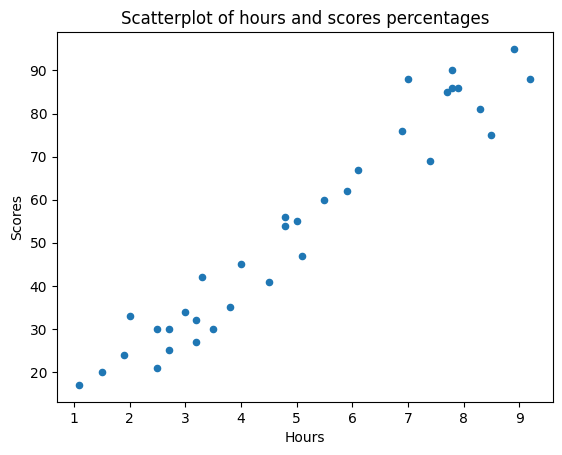

In [6]:
# Lets plot scatter graph between x=hours and y=scores variable

df.plot.scatter(x='Hours', y='Scores', title='Scatterplot of hours and scores percentages')

# Observ: There is a linear relation between x and y

In [ ]:
# Seperate your data into feature X and response y

X = df[['Hours']] # This is the feature that would predict the y
y = df['Scores']  # This is th prediction: labels/response/target

# Now we split the dataset into training / testing

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2) 

In [9]:
# Lets see how many records are in training and testing dataset

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (27, 1)
X_test shape: (7, 1)


## Feed training data to the model (i.e. train the model)

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

# This can take long time depending on size of training data
model.fit(X_train, y_train) 

LinearRegression()

In [12]:
# Lets make a prediction on score of a student who studies for hours=9.5,
# and check against the above plot

X_sample = [[9.5],]
X_df = pd.DataFrame(X_sample, columns=X_train.columns)

prediction = model.predict(X_df)

print("The prediction is", prediction)

The score is [98.65160013]


##  Evaluate the model by feeding the testing data

In [14]:
# step1: Lets make prediction on test data set
y_pred = model.predict(X_test)
print(y_pred)

[53.55695767 51.55275133 64.58009249 38.52541018 58.5674735  77.60743365
 48.54644184]


In [15]:
# step2: look at the actual test data
# print(X_test)
print(y_test.values)

[55 56 67 30 60 69 41]


In [54]:
# step3: Lets see the performance metric of the model 
from sklearn.metrics import r2_score

# Compute R-squared value
r2 = r2_score(y_test, y_pred)

print(f'R-squared: {r2:.4f}')  # closer to 1 is good

R-squared: 0.9256


## Pretty good r-square value

# STOP

# OPTIONAL

In [33]:
# Now lets the see absolute difference between the actual and prediction and also the percentage difference.

df_preds = pd.DataFrame({
    'actual_score': y_test.squeeze(),
    'predicted_score': y_pred.squeeze()})

df_preds['difference'] = (df_preds['actual_score'] - df_preds['predicted_score']).abs()

# Add the percentage difference column
df_preds['percentage_difference'] = (
    df_preds['difference'] / df_preds['actual_score']
) * 100

print(df_preds)

    hours  actual_score  predicted_score  difference  percentage_difference
15    8.9            95        92.112167    2.887833               3.039825
19    7.4            69        77.074120    8.074120              11.701623
27    4.0            45        42.987882    2.012118               4.471374
26    7.9            86        82.086802    3.913198               4.550230
8     8.3            81        86.096948    5.096948               6.292528
24    7.8            86        81.084266    4.915734               5.715970
21    4.8            54        51.008173    2.991827               5.540420
